# Lab work # 4: Clustering & Dim reduction

> Student name    - Maksym

> Student surname - Maliutin

> Group           - CS-31

### Imports & Dependencies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from tqdm import tqdm

# Препроцесинг та метрики
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                             normalized_mutual_info_score, adjusted_rand_score, fowlkes_mallows_score,
                             confusion_matrix)

# Зниження розмірності
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
import umap

# Алгоритми кластеризації
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering

# Для бонусного завдання
import hdbscan

# Налаштування графіків
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

c:\Users\SystemX\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Helper Functions

In [3]:
# Функції для візуалізації та оцінки якості кластеризації

def plot_2d(X_2d, labels, title="2D Візуалізація"):
    """Створює 2D діаграму розсіювання зменшених даних."""
    plt.figure(figsize=(10, 7))
    unique_labels = np.unique(labels)
    
    # Вибір палітри кольорів
    palette = sns.color_palette("bright", n_colors=len(unique_labels))
    
    sns.scatterplot(
        x=X_2d[:, 0], 
        y=X_2d[:, 1],
        hue=labels,
        palette=palette,
        legend="full",
        alpha=0.7
    )
    plt.title(title)
    plt.xlabel("Компонента 1")
    plt.ylabel("Компонента 2")
    plt.show()

def plot_3d_plotly(X_3d, labels, title="3D Візуалізація"):
    """Створює інтерактивну 3D діаграму розсіювання."""
    df_plot = pd.DataFrame({
        'Component 1': X_3d[:, 0],
        'Component 2': X_3d[:, 1],
        'Component 3': X_3d[:, 2],
        'label': labels
    })
    # Перетворюємо мітки на рядки, щоб Plotly сприймав їх як категорії
    df_plot['label'] = df_plot['label'].astype(str)
    
    fig = px.scatter_3d(
        df_plot, 
        x='Component 1', 
        y='Component 2', 
        z='Component 3',
        color='label',
        title=title,
        opacity=0.7
    )
    fig.update_traces(marker=dict(size=3))
    fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
    fig.show()

def evaluate_clustering(X, labels, true_labels, model=None, algorithm_info="k-means"):
    """Розраховує метрики якості кластеризації."""
    results = {}
    
    # Створення маски для основних точок (ігноруємо шум -1 для DBSCAN)
    is_core_mask = (labels != -1)
    has_outliers = not np.all(is_core_mask)
    X_core = X[is_core_mask]
    labels_core = labels[is_core_mask]
    
    results['algorithm'] = algorithm_info
    
    if has_outliers:
        results['num_clusters'] = len(np.unique(labels_core))
        results['num_outliers'] = np.sum(~is_core_mask)
    else:
        results['num_clusters'] = len(np.unique(labels))
        results['num_outliers'] = 0

    # Метрики без учителя (Unsupervised)
    # Потребують як мінімум 2 кластери
    if 1 < results['num_clusters'] < X_core.shape[0]:
        results['silhouette'] = silhouette_score(X_core, labels_core)
        results['davies_bouldin'] = davies_bouldin_score(X_core, labels_core)
        results['calinski_harabasz'] = calinski_harabasz_score(X_core, labels_core)
    else:
        results['silhouette'] = None
        results['davies_bouldin'] = None
        results['calinski_harabasz'] = None
        
    # WCSS (Inertia) тільки для K-Means
    if model is not None and hasattr(model, 'inertia_'):
        results['wcss_inertia'] = model.inertia_

    # Метрики з учителем (Supervised) - порівняння зі справжніми класами
    if true_labels is not None:
        results['nmi'] = normalized_mutual_info_score(true_labels, labels)
        results['ari'] = adjusted_rand_score(true_labels, labels)
        results['fmi'] = fowlkes_mallows_score(true_labels, labels)
    
    return results

### 1. Load and Prepare Data

In [4]:
# Load dataset
df = pd.read_csv("nasa.csv")

print("Original Shape:", df.shape)

# Drop identification columns, dates, and constant categorical columns that don't help clustering
cols_to_drop = [
    'Neo Reference ID', 'Name', 'Close Approach Date', 'Epoch Date Close Approach',
    'Orbit Determination Date', 'Orbiting Body', 'Equinox', 'Orbit ID'
]

# Check if columns exist before dropping to avoid errors
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df_clean = df.drop(columns=cols_to_drop)

# Encode Target: 'Hazardous' is Boolean (True/False) -> Convert to 1/0
if df_clean['Hazardous'].dtype == 'bool' or df_clean['Hazardous'].dtype == 'object':
    df_clean['Hazardous'] = df_clean['Hazardous'].astype(int)

# Separate X (Features) and y (Target)
X = df_clean.drop(columns=['Hazardous'])
y = df_clean['Hazardous']

# Check for any remaining non-numeric columns
print("Remaining non-numeric columns:", X.select_dtypes(include=['object']).columns.tolist())

X.head()

Original Shape: (4687, 40)
Remaining non-numeric columns: []


,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),Est Dia in Feet(max),Relative Velocity km per sec,...,Semi Major Axis,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion
0,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,933.308089,6.115834,...,1.407011,6.025981,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551
1,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,1071.581063,18.113985,...,1.107776,28.412996,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330
2,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,1698.341531,7.590711,...,1.458824,4.237961,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371
3,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,64.569144,11.173874,...,1.255903,7.905894,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277
4,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,933.308089,9.840831,...,1.225615,16.793382,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395


### 1.2 Preprocessing (Scaling)

In [5]:
# Scale the data using StandardScaler (Critical for K-Means, Spectral, DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier handling
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Data scaled successfully.")
X_scaled.describe().T.head()

Data scaled successfully.


,count,mean,std,min,25%,50%,75%,max
Absolute Magnitude,4687.0,-4.123482e-16,1.000107,-3.842670,-0.749954,-0.127260,0.772188,3.401342
Est Dia in KM(min),4687.0,-3.031972e-17,1.000107,-0.550947,-0.463129,-0.253834,0.133229,41.606318
Est Dia in KM(max),4687.0,-4.851156e-17,1.000107,-0.550947,-0.463129,-0.253834,0.133229,41.606318
Est Dia in M(min),4687.0,-1.091510e-16,1.000107,-0.550947,-0.463129,-0.253834,0.133229,41.606318
Est Dia in M(max),4687.0,-3.031972e-17,1.000107,-0.550947,-0.463129,-0.253834,0.133229,41.606318


### 2.1 Baseline Clustering - K-Means

In [6]:
# Since the target is binary (Hazardous vs Non-Hazardous), we expect 2 clusters roughly.

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Evaluate
km_results = evaluate_clustering(X_scaled.values, kmeans_labels, y, model=kmeans, algorithm_info="K-Means (k=2)")
print("K-Means Results:", km_results)

# Visualization on Raw Data (using first 2 features is usually messy, but let's see)
# We will rely on PCA/t-SNE later for better visuals.

K-Means Results: {'algorithm': 'K-Means (k=2)', 'num_clusters': 2, 'num_outliers': 0, 'silhouette': np.float64(0.2003854141801045), 'davies_bouldin': np.float64(1.9478787958230233), 'calinski_harabasz': np.float64(933.776144351022), 'wcss_inertia': 121150.30524652157, 'nmi': np.float64(0.03590664068398307), 'ari': 0.08344498633826723, 'fmi': np.float64(0.664269696683502)}


### 2.2 Baseline Clustering: Spectral Clustering

In [7]:
# Using a subset if data is too large for Spectral (Memory intensive)
if X_scaled.shape[0] > 5000:
    print("Data too large for standard Spectral Clustering in Lab environment. Subsampling to 2000 samples for this step.")
    X_subset = X_scaled.iloc[:2000]
    y_subset = y.iloc[:2000]
else:
    X_subset = X_scaled
    y_subset = y

spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42, n_jobs=-1)
spectral_labels = spectral.fit_predict(X_subset)

sp_results = evaluate_clustering(X_subset.values, spectral_labels, y_subset, model=spectral, algorithm_info="Spectral (k=2)")
print("Spectral Results:", sp_results)

Spectral Results: {'algorithm': 'Spectral (k=2)', 'num_clusters': 2, 'num_outliers': 0, 'silhouette': np.float64(0.16601929425512288), 'davies_bouldin': np.float64(2.0573954720158683), 'calinski_harabasz': np.float64(870.4237297196615), 'nmi': np.float64(0.0473053506273911), 'ari': 0.049812429680415424, 'fmi': np.float64(0.6270673456249299)}


### 2.3 Baseline Clustering: Agglomerative (Hierarchical)

In [8]:
agglo = AgglomerativeClustering(n_clusters=2, linkage='ward')
agglo_labels = agglo.fit_predict(X_scaled)

agg_results = evaluate_clustering(X_scaled.values, agglo_labels, y, model=agglo, algorithm_info="Agglomerative (Ward)")
print("Agglomerative Results:", agg_results)

Agglomerative Results: {'algorithm': 'Agglomerative (Ward)', 'num_clusters': 2, 'num_outliers': 0, 'silhouette': np.float64(0.1574431838196851), 'davies_bouldin': np.float64(2.1853954710578685), 'calinski_harabasz': np.float64(776.470472965693), 'nmi': np.float64(0.01448156710794393), 'ari': 0.026269156450917857, 'fmi': np.float64(0.6203255232194869)}


### 2.4 Baseline Clustering: DBSCAN

In [9]:
# DBSCAN is density based. 'eps' is the radius.
# Since data is scaled (std dev=1), eps=0.5 is a standard starting point, but space data can be sparse.

dbscan = DBSCAN(eps=2.0, min_samples=5) # Increased eps because outliers in space data can be far
dbscan_labels = dbscan.fit_predict(X_scaled)

db_results = evaluate_clustering(X_scaled.values, dbscan_labels, y, model=dbscan, algorithm_info="DBSCAN (eps=2.0)")
print("DBSCAN Results:", db_results)

DBSCAN Results: {'algorithm': 'DBSCAN (eps=2.0)', 'num_clusters': 26, 'num_outliers': np.int64(2042), 'silhouette': np.float64(-0.18530068155826124), 'davies_bouldin': np.float64(1.0132834671781124), 'calinski_harabasz': np.float64(11.753377711482521), 'nmi': np.float64(0.029940037906618335), 'ari': 0.026341818915243932, 'fmi': np.float64(0.5998527573635121)}


### 3.1 Dimensionality Reduction: PCA

Explained Variance Ratio (First 3 components): [0.32106338 0.18087173 0.13375711]
Total Explained Variance: 0.6357


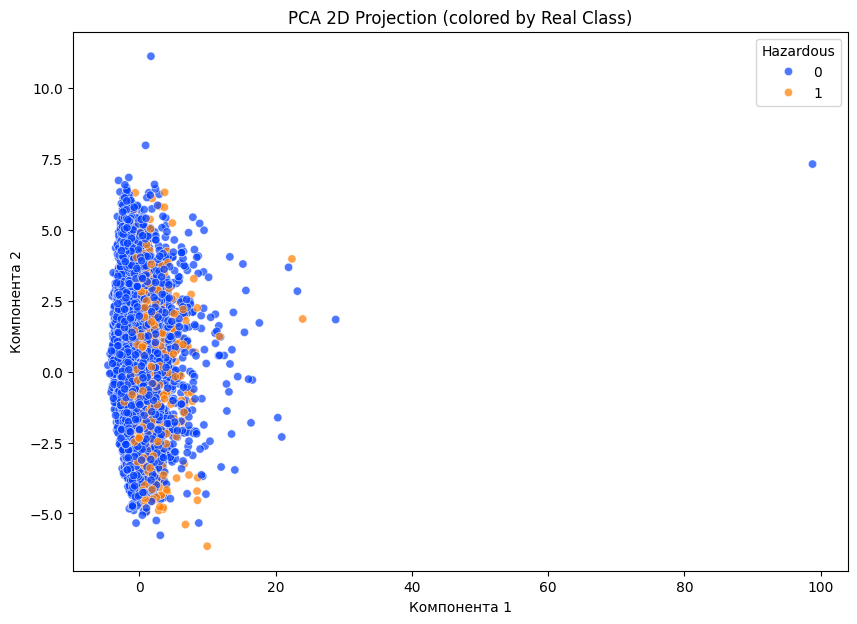

In [10]:
# PCA to 3 components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Explained Variance
print(f"Explained Variance Ratio (First 3 components): {pca.explained_variance_ratio_}")
print(f"Total Explained Variance: {np.sum(pca.explained_variance_ratio_):.4f}")

# Visualize 2D (first 2 components)
plot_2d(X_pca[:, :2], y, title="PCA 2D Projection (colored by Real Class)")

# Visualize 3D
plot_3d_plotly(X_pca, y, title="PCA 3D Projection")

### 3.2 Dimensionality Reduction: t-SNE

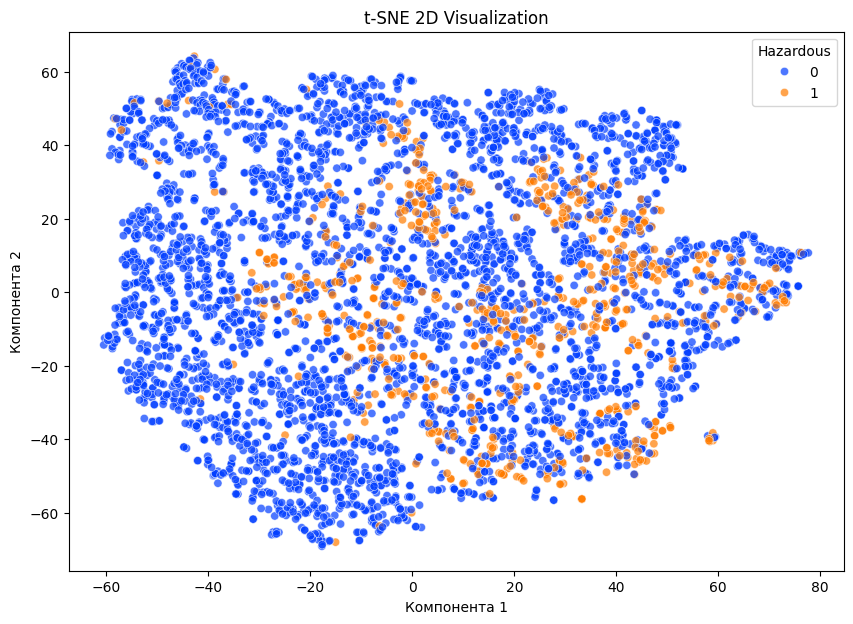

t-SNE Trustworthiness score: 0.9938


In [11]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne_2d = tsne.fit_transform(X_scaled)

plot_2d(X_tsne_2d, y, title="t-SNE 2D Visualization")

# Trustworthiness (Metric for DR quality - preservation of local structure)
score_tsne = trustworthiness(X_scaled, X_tsne_2d, n_neighbors=5)
print(f"t-SNE Trustworthiness score: {score_tsne:.4f}")

tsne_3d = TSNE(n_components=3, random_state=42, perplexity=30, n_iter=1000)
X_tsne_3d = tsne_3d.fit_transform(X_scaled)
plot_3d_plotly(X_tsne_3d, y, title="t-SNE 3D Visualization")

### 3.3 Dimensionality Reduction: UMAP

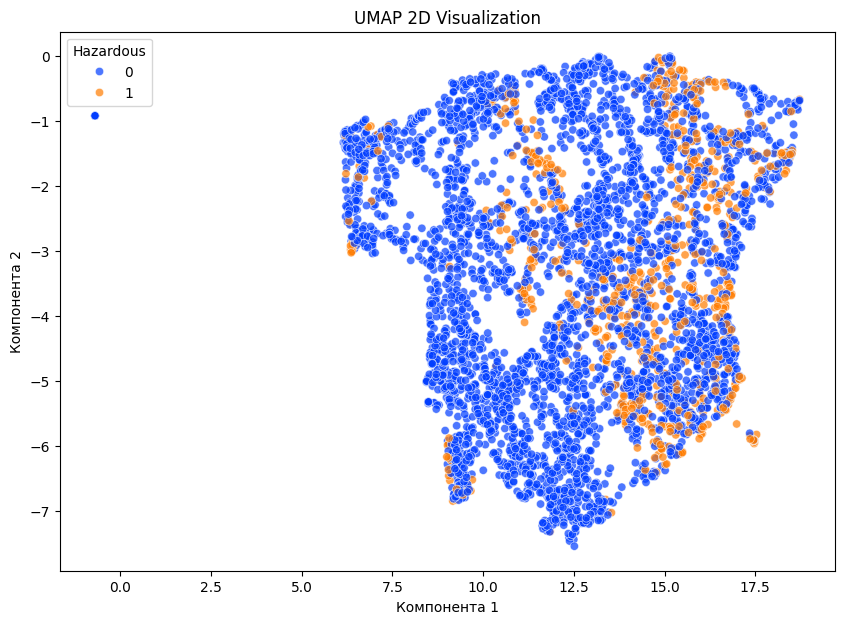

UMAP Trustworthiness score: 0.9607


In [12]:
umap_model_2d = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap_2d = umap_model_2d.fit_transform(X_scaled)

plot_2d(X_umap_2d, y, title="UMAP 2D Visualization")

# UMAP 3D
umap_model_3d = umap.UMAP(n_components=3, random_state=42)
X_umap_3d = umap_model_3d.fit_transform(X_scaled)
plot_3d_plotly(X_umap_3d, y, title="UMAP 3D Visualization")

# Trustworthiness
score_umap = trustworthiness(X_scaled, X_umap_2d, n_neighbors=5)
print(f"UMAP Trustworthiness score: {score_umap:.4f}")

--- Clustering on PCA Data ---


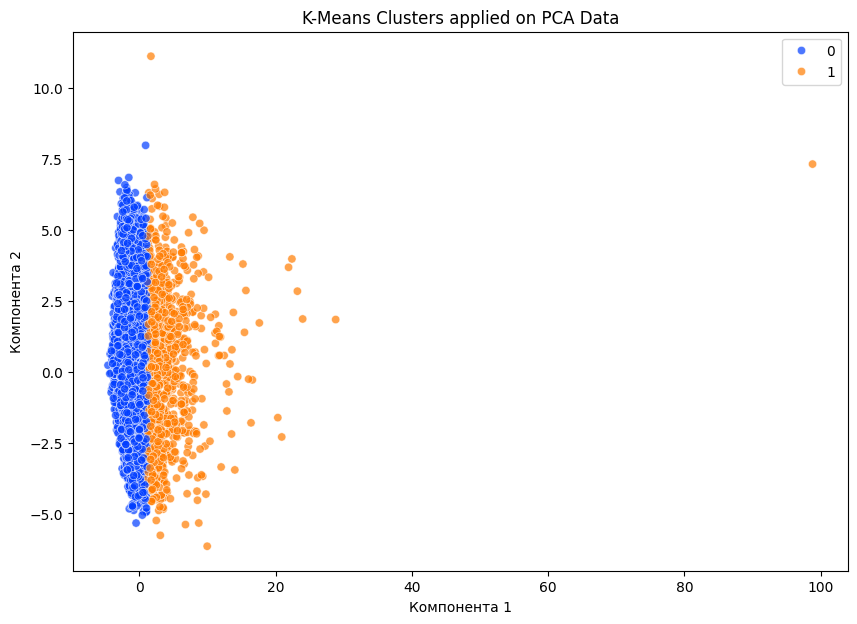

{'algorithm': 'K-Means on PCA (2D)', 'num_clusters': 2, 'num_outliers': 0, 'silhouette': np.float64(0.38852947563988144), 'davies_bouldin': np.float64(1.1023258813836347), 'calinski_harabasz': np.float64(2029.7052757342994), 'wcss_inertia': 50885.3802254652, 'nmi': np.float64(0.027320819004887156), 'ari': 0.09559573663765368, 'fmi': np.float64(0.702111451167401)}


In [13]:
# 4.1 Clustering on Reduced Data: K-Means on PCA Data (2D)

print("--- Clustering on PCA Data ---")
# We use the 2D PCA data generated in step 3.1 (X_pca[:, :2])

kmeans_pca = KMeans(n_clusters=2, random_state=42)
labels_pca_km = kmeans_pca.fit_predict(X_pca[:, :2])

# Visualize the NEW clusters on the PCA plot
plot_2d(X_pca[:, :2], labels_pca_km, title="K-Means Clusters applied on PCA Data")

# Evaluate
results_pca_km = evaluate_clustering(X_pca[:, :2], labels_pca_km, y, model=kmeans_pca, algorithm_info="K-Means on PCA (2D)")
print(results_pca_km)

### 4.2 Clustering on Reduced Data: K-Means on UMAP Data (2D)

--- Clustering on UMAP Data ---


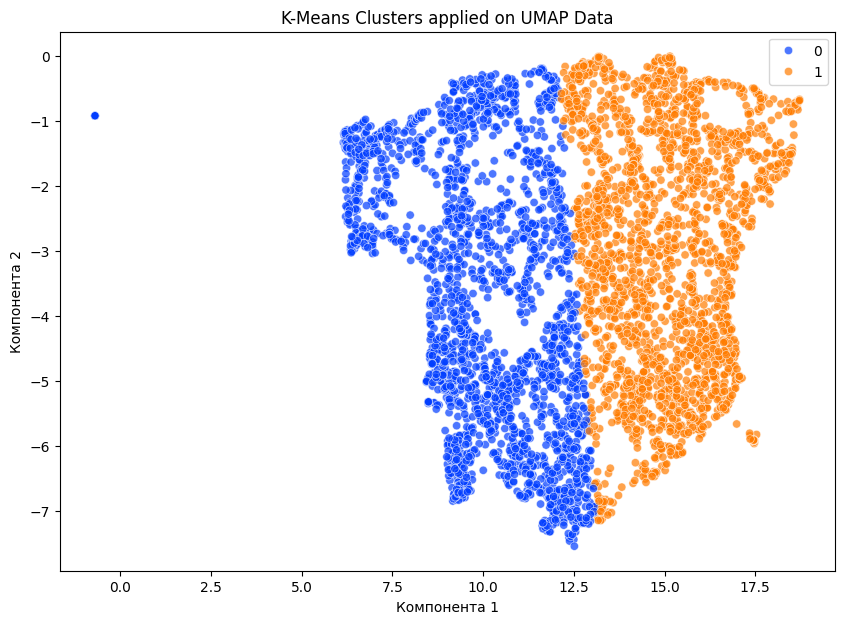

{'algorithm': 'K-Means on UMAP (2D)', 'num_clusters': 2, 'num_outliers': 0, 'silhouette': np.float32(0.4230652), 'davies_bouldin': np.float64(0.932156350586467), 'calinski_harabasz': np.float32(4568.583), 'wcss_inertia': 31098.279296875, 'nmi': np.float64(0.051635275282892926), 'ari': 0.02893778222999606, 'fmi': np.float64(0.6159382321828896)}


In [14]:
print("--- Clustering on UMAP Data ---")

kmeans_umap = KMeans(n_clusters=2, random_state=42)
labels_umap_km = kmeans_umap.fit_predict(X_umap_2d)

# Visualize the NEW clusters on the UMAP plot
plot_2d(X_umap_2d, labels_umap_km, title="K-Means Clusters applied on UMAP Data")

# Evaluate
results_umap_km = evaluate_clustering(X_umap_2d, labels_umap_km, y, model=kmeans_umap, algorithm_info="K-Means on UMAP (2D)")
print(results_umap_km)

### 5. DBCV (Density-Based Clustering Validation) using HDBSCAN library

In [15]:
# Ця метрика краще підходить для оцінки DBSCAN, ніж Silhouette score,
# оскільки вона враховує щільність кластерів, а не тільки відстань між центрами.

# Переконуємося, що мітки є цілими числами
dbscan_labels = dbscan_labels.astype(int)

try:
    # Розрахунок індексу валідності
    # Передаємо оригінальні масштабовані дані та отримані мітки
    dbcv_score = hdbscan.validity.validity_index(X_scaled.values, dbscan_labels)
    
    print(f"Параметри DBSCAN: eps=2.0, min_samples=5")
    print(f"Silhouette Score: {silhouette_score(X_scaled, dbscan_labels):.4f}")
    print(f"DBCV Score: {dbcv_score:.4f}")
    print("Інтерпретація: DBCV змінюється від -1 до 1. Вище значення означає кращу щільність.")
    
except Exception as e:
    print(f"Не вдалося розрахувати DBCV: {e}")

Параметри DBSCAN: eps=2.0, min_samples=5
Silhouette Score: -0.3007
DBCV Score: -0.1414
Інтерпретація: DBCV змінюється від -1 до 1. Вище значення означає кращу щільність.


## 6. Analysis and Conclusions

### Summary of Results: Clustering Quality Comparison

| Method | Data Source | Silhouette Score (Higher is Better) | ARI (vs True Labels) (Higher is Better) | NMI (vs True Labels) (Higher is Better) |
| :--- | :--- | :--- | :--- | :--- |
| **Baseline K-Means** | Original Scaled X | 0.200 | 0.083 | 0.036 |
| **Baseline Spectral** | Original Scaled X | 0.166 | 0.050 | 0.047 |
| **Baseline Agglomerative** | Original Scaled X | 0.157 | 0.026 | 0.014 |
| **Baseline DBSCAN** | Original Scaled X | -0.185 | 0.026 | 0.030 |
| **K-Means on PCA** | PCA 2D | 0.389 | **0.096** | 0.027 |
| **K-Means on UMAP** | UMAP 2D | **0.423** | 0.029 | **0.052** |

---

### Key Findings and Conclusions

#### 1. Ефективність Зниження Розмірності (DR)

* **PCA** ефективно зберегла інформацію (**63.57%** дисперсії у 3-х компонентах) завдяки високій кореляції ознак у датасеті.
* **UMAP** та **t-SNE** показали високу надійність (**Trustworthiness** близько 0.96–0.99), підтверджуючи, що вони якісно відобразили локальну структуру даних. 

#### 2. Вплив DR на Кластеризацію

* **Якість Кластерів (Silhouette):** Зниження розмірності значно **покращило** внутрішню якість кластерів. **K-Means на UMAP** досяг найкращого результату **(0.423)**, що свідчить про створення більш компактних і чітко розділених груп.
* **Відповідність Справжнім Класам (ARI/NMI):** Усі показники ARI та NMI залишаються **дуже низькими** (максимум ARI = 0.096). Це ключовий висновок: **кластери, знайдені алгоритмами (незалежно від DR), не збігаються зі справжнім бінарним класом "Hazardous"**.

#### 3. Кращий Алгоритм

* **Найкраща Внутрішня Структура:** **K-Means (на UMAP)**. Цей метод найкраще впорався з компактним групуванням.
* **DBSCAN** показав найгірші результати **(Silhouette -0.185)** та виявив велику кількість **викидів (2042)**. Це вказує на нерівномірний розподіл астероїдів.
* **DBCV Score (-0.1414)** підтверджує, що щільнісна кластеризація (DBSCAN) дала **низькоякісні** результати для цього датасету.

Загальний Висновок: Успішне зниження розмірності **покращує** формування компактних груп, але ці групи **не є інформативними** для визначення небезпеки астероїда (тобто, unsupervised learning не відтворює true labels).